#### 1. Introduction to Inference-time Scaling

IFT -> Spending more compute at answer generation. (Why - too improve Quality fo answers). hence generating more tokens and thinking longer, sampling multiple answers or refiniing its answers. Hence -> Generating longer responses & generating multiple responses 


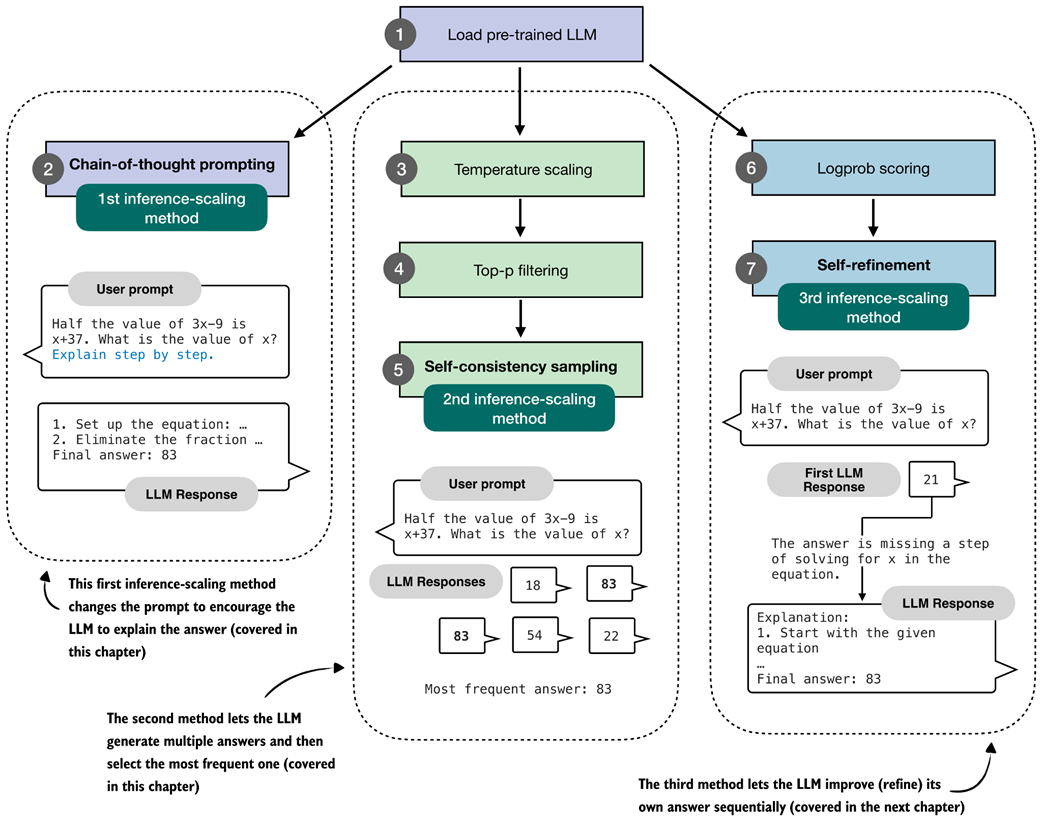




In [ ]:
from pathlib import Path
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)
 
out_dir = Path("../../_models/qwen3").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
     
device = get_device()
device = torch.device("cpu")
 
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False,
    local_dir=str(out_dir))

Using Apple Silicon GPU (MPS)
✓ /Users/monusingh/work-share/code-blogs-articles/_models/qwen3/qwen3-0.6B-base.pth already up-to-date


In [ ]:
from reasoning_from_scratch.ch03 import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [11]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache
 
 
def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False, 
    generate_func=None,
    **generate_kwargs
):
 
    if generate_func is None:
        generate_func = generate_text_basic_stream_cache

    # converts prompts to tokenIDs, moves to device, add batch dimension    
    input_ids = torch.tensor(
        tokenizer.encode(prompt), device=device
        ).unsqueeze(0)
 
    generated_ids = []
    # Yields one token ID at a time
    for token in generate_func(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,
    ):
        # removes dimensions
        next_token_id = token.squeeze(0) 
        # .item() -> converts to Python int
        generated_ids.append(next_token_id.item())
 
        if verbose:
            print(
                tokenizer.decode(next_token_id.tolist()),
                end="",
                flush=True
            )
    return tokenizer.decode(generated_ids)
 

In [12]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache
)

 \boxed{20}

#### 2. Better Responses via CoT:

Chain-of-thought prompting is a classic, simple, and effective technique that modifies the input prompt to encourage the LLM to generate an explanation or so-called chain-of-though

In [8]:
prompt_cot = prompt + " \n\nExplain step by step."
 
response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
We are given that half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

-----
As we can see, the model now writes a lengthy step-by-step explanation and, in this case, now arrives at the correct answer.

This simple chain-of-thought prompting is a good demonstration of the inference-time scaling trade-off. While the model now answers correctly, it expends many more tokens than before. As discussed in chapter 2, LLMs generate text one token at a time, and each additional token requires another forward pass through the model. So these intermediate reasoning steps do not just make the answer longer, they also directly increase latency, compute cost, and often API cost in practice.

Note that while the model generates the correct answer in this case, not all problems benefit from chain-of-thought prompting. On simple problems, it can even sometimes degrade the model's performance, as the model might sometimes generate erroneous explanations and mislead itself. This phenomenon is also known as "overthinking."

##### Why chain-of-thought can improve accuracy
Chain-of-thought prompting asks the model to write out the intermediate steps that lead to a final answer. This helps in two practical ways.

First, walking through the steps gives the model more opportunities to correct itself.

Second, step-by-step reasoning matches how many training examples are written. For instance, large math and logic datasets often contain detailed solutions, so asking for a chain of thought aligns the model with patterns it has already learned.

Overall, chain-of-thought answering does not provide the model with new knowledge, but it changes how the model uses its existing knowledge. Often, this shift can lead to more reliable answers. This is especially true for math, code, logic problems, and other sorts of multi-step problems.

#### Controlling Output diversity with Temperature Scaling

Chain-of-thought prompting can be seen as a sequential technique as we extend the number of next-token prediction steps. 

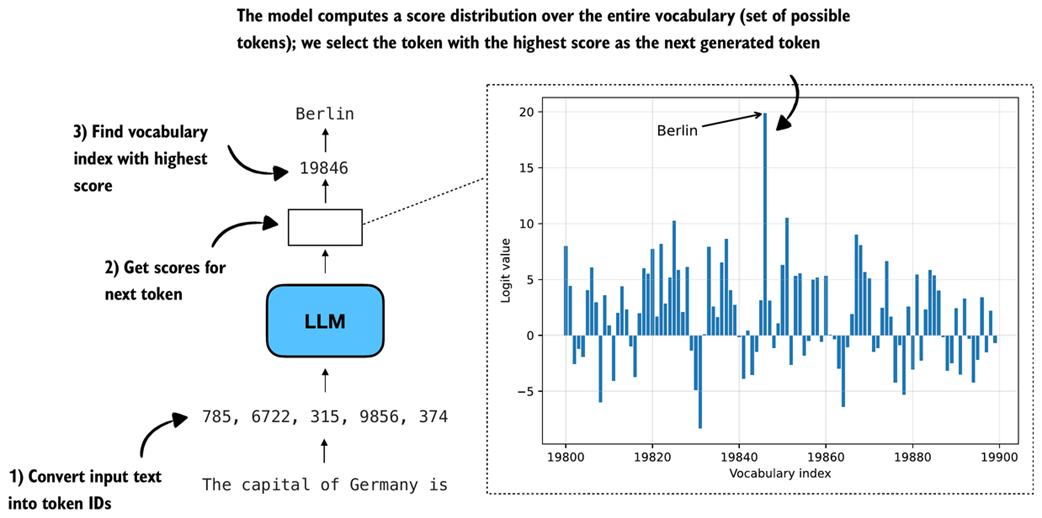

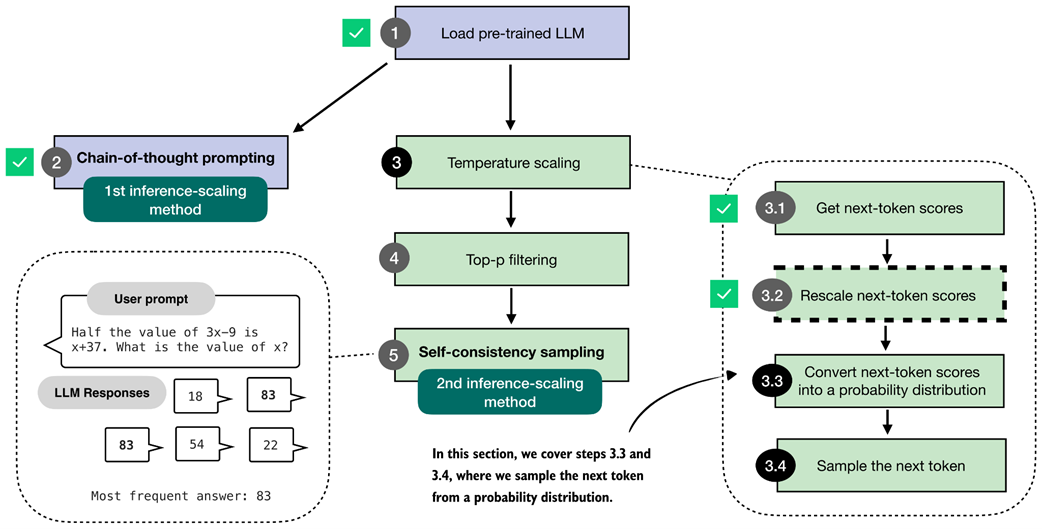

In [ ]:
ex_prompt = "The capital of Germany is"
 
response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)



 Berlin

In [26]:
# Step 1 ------> Prompts to Token IDs
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)
print(input_token_ids)
print(input_token_ids.shape)

# Step 2 ---------> Scores of Output Token
# Model output scoreas are also called logits. 

# interested in last token only
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token : `{tokenizer.decode([max_token_id])}`")


tensor([[ 785, 6722,  315, 9856,  374]])
torch.Size([1, 5])
torch.Size([1, 151936])
Token ID: 19846
Decoded token : ` Berlin`


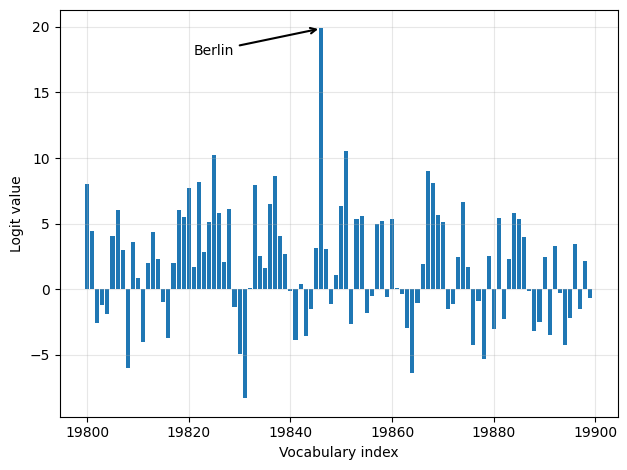

In [ ]:
import matplotlib.pyplot as plt
 
def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    x = torch.arange(start, end) # x-axis label
    logits_section = next_token_logits[0, start:end].float().cpu()
 
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)
 
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )
 
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
 
plot_scores_bar(next_token_logits)

#### Rescaling token scores (logits) via a temperature parameter

Rescaling here means adjusting the magnitude of the scores so the sampling step becomes more or less sensitive to the score differences.

Temperature, or rather a chosen temperature parameter, changes how sharp or spread out the logits (token scores) are, which in turn affects how the next token is selected.

In practice, temperature values are expected to be positive numbers. A temperature of 1.0 means no change, since dividing a number by 1 is the number itself.

A temperature lower than 1.0 makes the distribution sharper (which will make the model more confident when we select the next token). Temperatures higher than 1.0 flatten the logits, which can make the sampling more diverse. In other words, higher temperatures reduce the probability gap between the top token and lower-ranked tokens, which increases the chance that sampling will pick a non-maximum token.

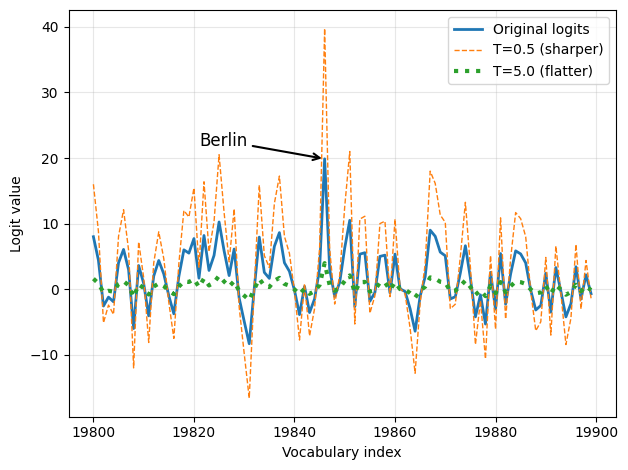

In [28]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature
 

def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()
 
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
 
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )
 
    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )
 
    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
 
plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

If a token such as "Berlin" stands out more strongly than the alternatives, it will become more likely to be selected later. If the gaps shrink, lower-ranked tokens become more likely to be selected compared to before

##### Sampling the next token from a probability distribution


Probability sum: tensor(1., dtype=torch.bfloat16)


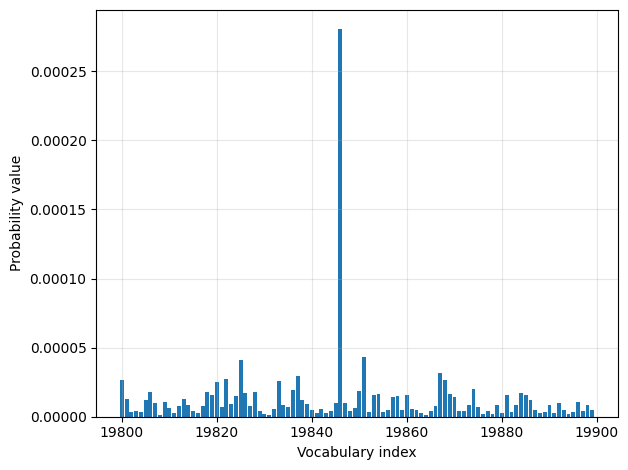

Token ID 19,846 probability: tensor([0.0003], dtype=torch.bfloat16)


In [54]:
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# The torch.softmax function normalizes the logit values 
# into values in the range between 0 and 1,
# and such that the values sum to 1,
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)


print("Probability sum:", torch.sum(next_token_probas))

plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

print("Token ID 19,846 probability:", next_token_probas[:, 19846])

##### The softmax function under the hood

$$softmax(zᵢ) = exp(zᵢ) / Σⱼ exp(zⱼ)$$

Here, z is a a vector of real-valued inputs

$$z = [z₁, z₂, …, zₙ],$$
where

n is the number of elements in the vector,
i is the index of the current element (1 ≤ i ≤ n),
j is the index used to sum over all elements (1 ≤ j ≤ n),
This produces a normalized probability for each element zᵢ, such that

$$Σᵢ softmax(zᵢ) = 1$$


The reason the value is so small is that we are using a large temperature, which makes it easier to plot this value next to the other token values. If we change the temperature from 5 to 0.5, the probability score increases from 0.0003 to 0.3398, and the probability scores of the other tokens will be even closer to 0.



In [42]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[65094]])


This code returns token ID 65,094, which corresponds to the word " mistress". 

Note that the word doesn't make sense in our context, "The capital of Germany is", and it was selected randomly in this case and influenced by the high-temperature setting, which encourages tokens other than " Berlin" to be sampled.

The torch.multinomial function samples the vocabulary indices proportional to their probabilities. In other words, vocabulary indices with higher probabilities are more likely to be sampled. If we repeated the sampling a very large number of times, we would sample the vocabulary index corresponding to the token " Berlin" with 0.03% probability, given a temperature of 5.

In [45]:
# torch.multinomial to randomly select num_samples indices proportional to their probabilities
# torch.bincount counts how often each index appears


def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
        # replacement=True , to select same token again
    )
    counts = torch.bincount(samples.squeeze(0), minlength=1)
    
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

##### Multinomial sampling

Multinomial sampling is the procedure used to pick the next token given a probability distribution over the vocabulary, like the softmax probability scores. In multinomial sampling, instead of always selecting the most likely token (known as greedy decoding), we draw one token at random, where tokens with higher probability are more likely to be selected. This randomness is important for generating diverse responses, which we later use in self-consistency.

To illustrate it further we can think of the probability scores as a set of weighted choices. For example, a token with probability 0.40 is four times as likely to appear as one with probability 0.10, but both remain possible outcomes.

Greedy decoding would always return "Berlin."

Multinomial sampling instead draws one token according to these weights. Across a very large number of draws, "Berlin" will appear most often (70% of the time), "Munich" sometimes (20% of the time), and "Hamburg" only occasionally (10% of the time).

This variability is what allows us to generate multiple candidate answers for self-consistency.

In [47]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)
# These are all nonsense tokens in the context of the "The capital of Germany is" query.
# The reason for these nonsensical results is that we used a temperature value that is much too high.

'}': 2x
' </': 2x
' represent': 2x
' Inf': 2x
'()*': 2x
' beside': 2x
' Kob': 2x
'�': 2x


In [ ]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)

count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)
print(probas_lowT[0, 19_846]) # Prob of drawing Berlin is 42%

#  The underscore responses (" ____") are likely due to the model having seen text in the form of a quiz with a placeholder, e.g., "The capital of Germany is ____".

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x
tensor(0.4199, dtype=torch.bfloat16)


#### Adding temperature scaling to the text generation function

##### Choosing temperature settings
In practice, temperature selection depends on the goal. A temperature of 0.0 corresponds to greedy decoding, where we always pick the highest-probability token. Small nonzero values such as 0.3-0.8 are often useful when we want a bit more diversity without making the output too erratic. Much higher values make the model explore more broadly, which can be useful for creative generation or broad search, but often hurts reliability on tasks where we want the single most likely answer.

In [53]:
from reasoning_from_scratch.qwen3 import KVCache
 
@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
 
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):
 
        ########################################
        # NEW:
        orig_device = token_ids.device
 
        if temperature is None or temperature == 1.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
 
        else: 
            logits = scale_logits_by_temperature(out, temperature)
            probas = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)
            
        #########################################
        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break
 
        yield next_token
        out = model(next_token, cache=cache)[:, -1]

torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 \boxed{$x = \frac{90}{7}$}

#### Balancing diversity and coherence with top-p sampling

We improve the sampling process by adding a top-p filter (figure 4.12) such that very low-confidence tokens are not sampled by accident. The top-p sampling process described in this section is also known as nucleus sampling.

The purpose of top-p filtering in this section is to drop low-probability tokens so that only the most plausible options remain during sampling. This reduces the chance of producing tokens that do not fit the context.


Figure 4.12 summarizes the four steps that make up the top-p filter: sorting the token probabilities (4.1), computing their cumulative sum (4.2), selecting the subset that satisfies the top-p cutoff (4.3), and renormalizing the remaining probabilities so that they again form a valid distribution (4.4).

The renormalization step is necessary because, once we remove all low-probability tokens, the remaining probabilities no longer sum to one. To sample correctly, we rescale these remaining values so they represent a proper probability distribution.



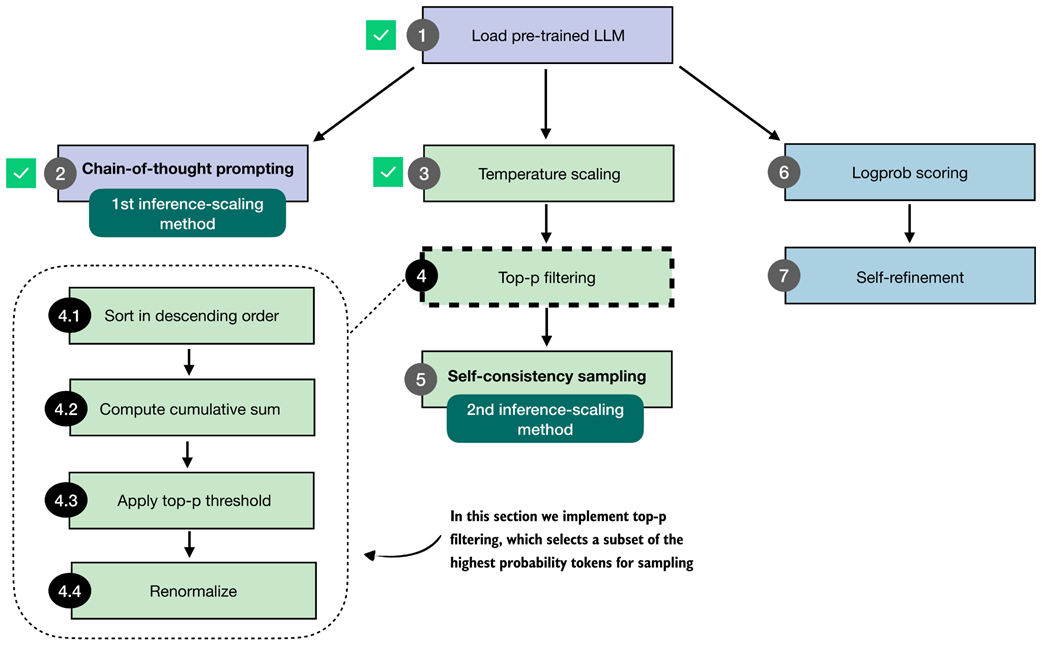

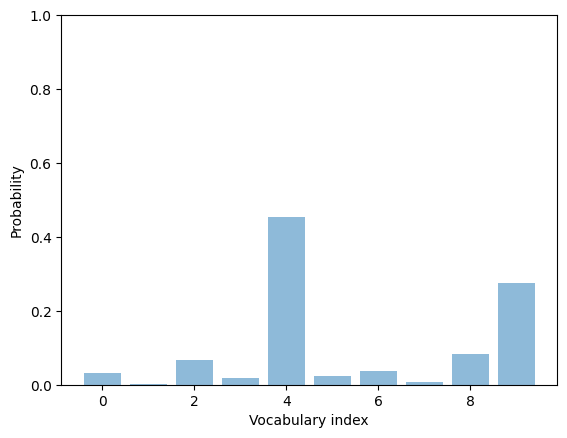

In [56]:
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)
 
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)
 
plt.bar(
    torch.arange(len(toy_probas)), toy_probas,
    alpha=0.5
)
 
plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

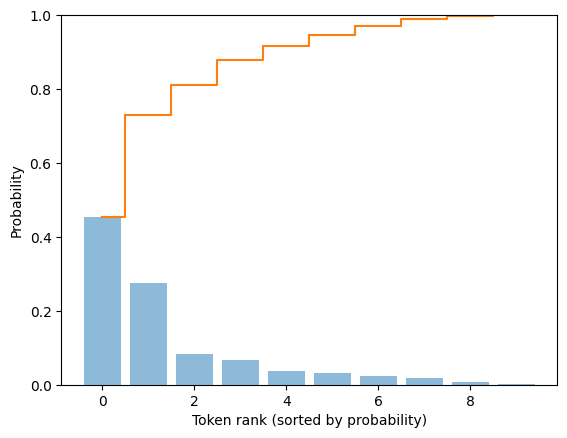

In [57]:
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)
cumsum = torch.cumsum(sorted_probas, dim=-1)
 
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum, 
    where="mid", color="C1", label="Cumulative sum"
)
 
plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

Now that we have the cumulative probability sum, we can implement the core top-p filtering step. The "p" in top-p stands for probability, and top-p can be translated to "keep the smallest set of tokens whose cumulative probability stays below or equal to p." 


In [ ]:
top_p = 0.8
keep_mask = cumsum <= top_p
# marks all tokens whose cumulative probability mass does not yet exceed the threshold p

n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)
 
# Now, a more common variant of top-p filtering includes the token that exceeds the threshold:

keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)
 

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2
Tokens kept: 3


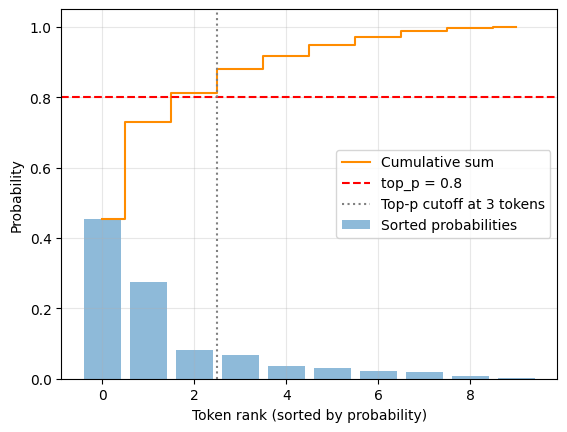

In [60]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)
 

plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)
 
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()
 

In [61]:
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)
print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [62]:
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


#### Adding a top-p filter to the text generation function


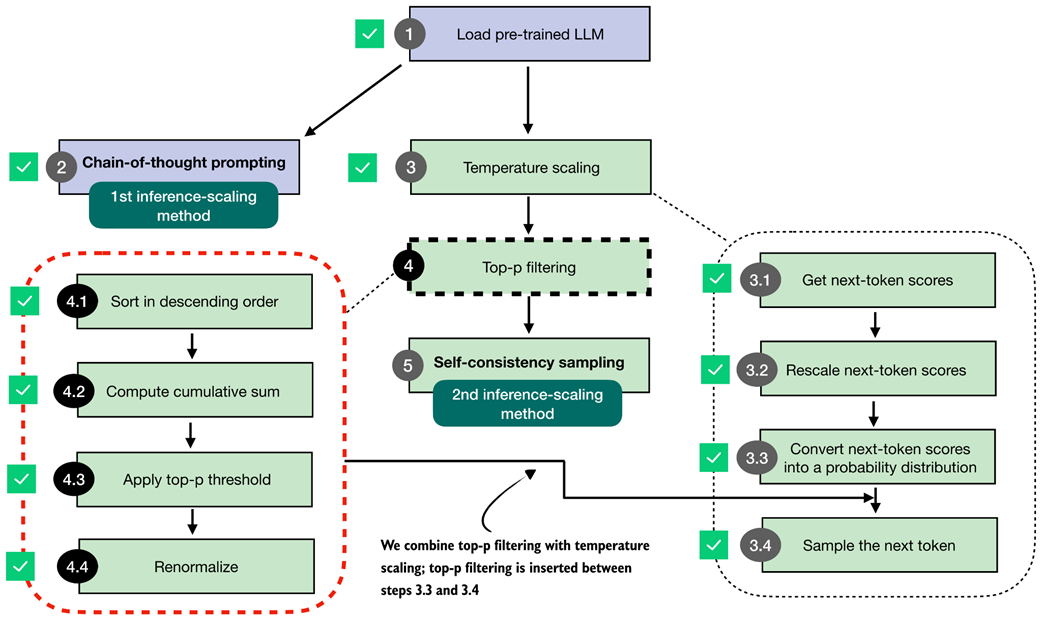

In [64]:
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas
 
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)
    cumprobas = torch.cumsum(sorted_probas, dim=1)
 
    prefix = cumprobas - sorted_probas
    keep = prefix < top_p
    keep[:, 0] = True
 
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )

    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)
 

    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

# Next, we rescale the logits into probability scores 
# and apply the temperature scaling with a temperature of 0.35, similar to before:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)
count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

torch.Size([1, 151936])
' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x
' Berlin': 534x
' ____': 217x
' ______': 249x


In [65]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
 
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):
 
        orig_device = token_ids.device
 
        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
 
        else:
            logits = scale_logits_by_temperature(out, temperature)
            probas = torch.softmax(logits, dim=-1)
 
            probas = top_p_filter(probas, top_p)
 
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)
 
        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break
 
        yield next_token
        out = model(next_token, cache=cache)[:, -1]



torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8, 
)

 \boxed{18}

##### Top-k filtering

Top-k filtering is another way to limit the set of candidate next tokens during sampling.

Instead of keeping all tokens whose cumulative probability stays below a threshold (as in top-p), top-k keeps only the k most likely tokens based on the model's logits.

After sorting the vocabulary by probability, everything past the first k entries is removed.

The remaining k tokens are then renormalized and sampled from.

In short, top-k keeps a fixed number of the most likely tokens, whereas top-p keeps a variable number of tokens depending on their cumulative mass.

#### Improving response accuracy with self-consistency


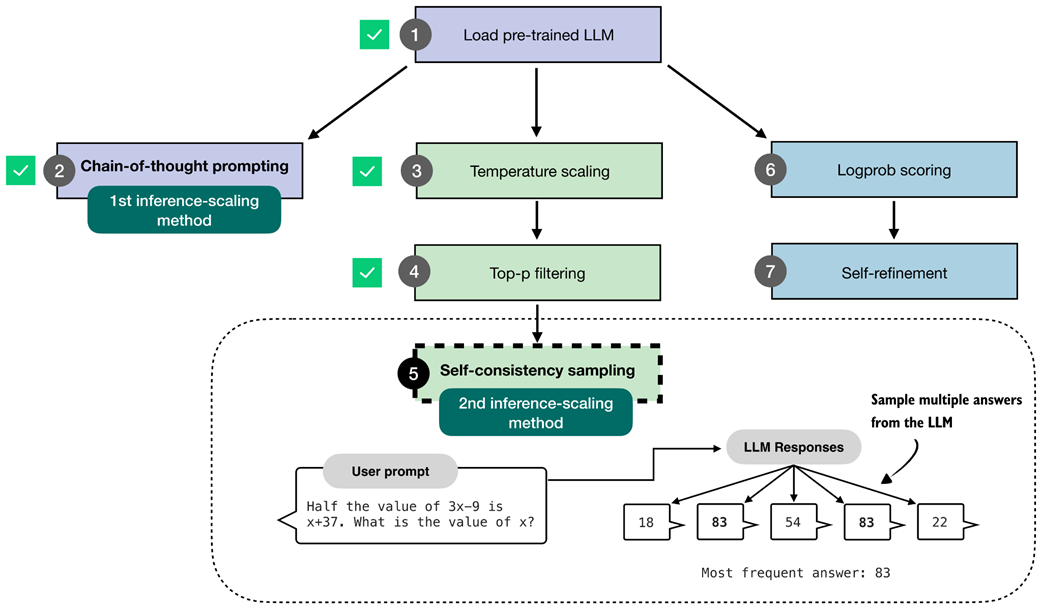

The self-consistency code implementation, thanks to the generate_text_stream_concat_flex function, is relatively straightforward, and the main procedure can be summarized in three main steps as illustrated in figure 4.18.


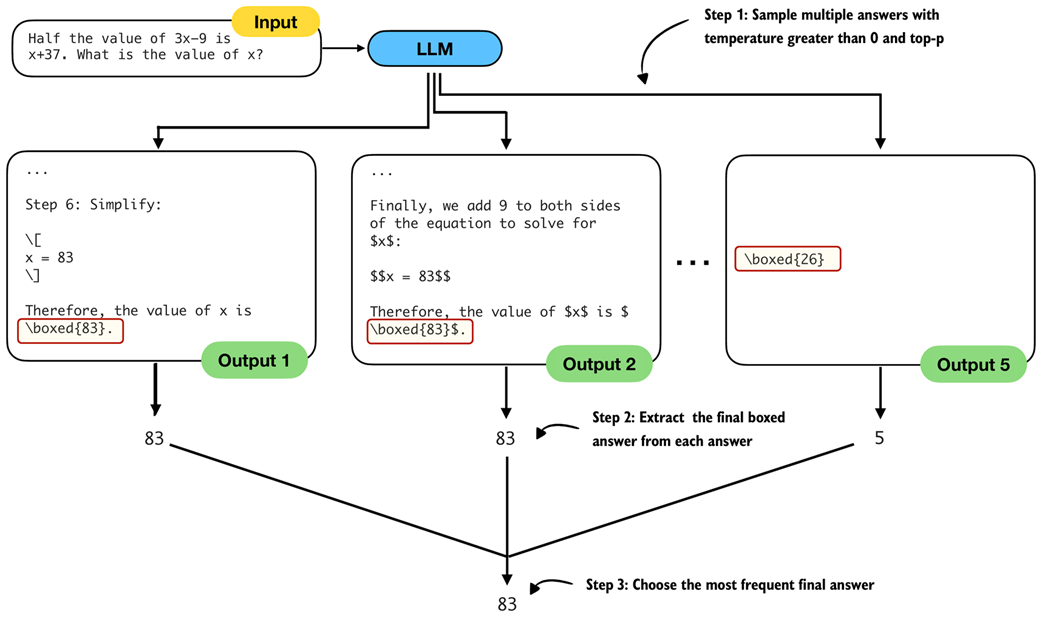

Figure 4.18 The three main steps for implementing self-consistency sampling. First, we generate multiple answers for the same prompt using a temperature greater than zero and top-p filtering to generate different answers. Second, we extract the final boxed answer from each generated solution. Third, we select the most frequently extracted answer as the final prediction.


In [66]:
from reasoning_from_scratch.ch03 import extract_final_candidate
from collections import Counter
 
def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9, max_new_tokens=2048,
    show_progress=True, show_long_answer=False, seed=None,
):
    full_answers, short_answers = [], []
 
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)
 
        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, device=device,
            max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p,
        )
 
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")
 
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)
 
    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None
 
    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

In [67]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '83'
[Sample 5/5] → '61'


In [68]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → 'x = 83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


Experiments on the MATH-500 dataset show that combining chain-of-thought prompting with self-consistency can substantially boost accuracy compared to the baseline without sampling, at the cost of much longer runtimes.
The central trade-off of inference-time scaling: higher accuracy in exchange for more compute.
